# MARTA GNN – Delay Risk Prediction Demo

1. Load demo dataset
2. Inspect data & graph
3. Train GCN and MLP baseline
4. Evaluate and compare

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [2]:
import sys, os, logging, importlib
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src"))
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
%matplotlib inline

from marta_gnn.training.trainer import Trainer, build_model, model_forward
from marta_gnn.training.evaluation import evaluate
import marta_gnn.visualization.plots as _plots_mod
importlib.reload(_plots_mod)
from marta_gnn.visualization.plots import (
    plot_training_curves, plot_confusion_matrix,
    plot_roc_curve, plot_graph_layout, plot_delay_distribution,
    plot_model_comparison,
)
from sklearn.metrics import RocCurveDisplay

print(f"CUDA: {torch.cuda.is_available()}")

CUDA: False


## 1. Hyperparameters

Adjust the values below before training. Re-run this cell and the training cells to experiment.

In [ ]:
# ── Model architecture ──
HIDDEN_DIM   = 64      # hidden layer size
NUM_LAYERS   = 2       # GCN conv layers
DROPOUT      = 0.5     # dropout rate

# ── Optimiser ──
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-3

# ── Training schedule ──
EPOCHS   = 200
PATIENCE = 50

# ── Data splits ──
TRAIN_RATIO = 0.6
VAL_RATIO   = 0.2
TEST_RATIO  = 0.2
SEED        = 10

# ── Feature / label settings ──
DELAY_THRESHOLD = 300

# ─────────────────────────────────────────────
cfg = {
    "data":     {"use_mock": True, "mock_num_stops": 800, "mock_num_routes": 30,
                 "mock_num_trips": 200, "processed_dir": "data/processed"},
    "features": {"time_bins": 24, "delay_threshold_seconds": DELAY_THRESHOLD,
                 "historical_window_days": 7},
    "model":    {"type": "gcn", "hidden_dim": HIDDEN_DIM, "num_layers": NUM_LAYERS,
                 "dropout": DROPOUT, "learning_rate": LEARNING_RATE,
                 "weight_decay": WEIGHT_DECAY, "epochs": EPOCHS,
                 "patience": PATIENCE, "batch_size": 32},
    "training": {"train_ratio": TRAIN_RATIO, "val_ratio": VAL_RATIO,
                 "test_ratio": TEST_RATIO, "seed": SEED},
    "logging":  {"level": "INFO", "file": ""},
}

logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)
logging.getLogger("marta_gnn.training.trainer").setLevel(logging.INFO)


def train_and_evaluate(model_type, data, base_cfg=None):
    """Train a model and return (model, history, results). Reduces repetition."""
    c = base_cfg or cfg
    c = {k: (dict(v) if isinstance(v, dict) else v) for k, v in c.items()}
    c["model"]["type"] = model_type
    model = build_model(c, in_dim=data.x.shape[1])
    history = Trainer(c).train(model, data)
    results = evaluate(model, data)
    return model, history, results

## 2. Load Demo Dataset

In [ ]:
from marta_gnn.data.demo import load_demo_dataset

data, mock = load_demo_dataset(cfg)

print(f"Nodes:     {data.num_nodes}")
print(f"Edges:     {data.edge_index.shape[1]}")
print(f"Features:  {data.x.shape[1]}")
print(f"Labels:    {data.y.unique(return_counts=True)}")
print(f"Train/Val/Test: {data.train_mask.sum()}/{data.val_mask.sum()}/{data.test_mask.sum()}")

Nodes:     200
Edges:     1254
Features:  12
Labels:    (tensor([0, 1]), tensor([168,  32]))
Train/Val/Test: 119/39/42


## 3. Inspect Data

In [4]:
for name, df in mock.items():
    print(f"{name:15s}: {len(df):6d} rows")

mock["stops"].head()

stops          :    200 rows
routes         :     10 rows
trips          :     50 rows
stop_times     :    677 rows
realtime       :    677 rows


,stop_id,stop_name,stop_lat,stop_lon,wheelchair_boarding
0,STOP_0000,Mock Stop 0,33.768283,-84.369746,1
1,STOP_0001,Mock Stop 1,33.687601,-84.305551,0
2,STOP_0002,Mock Stop 2,33.795027,-84.384565,2
3,STOP_0003,Mock Stop 3,33.806434,-84.351364,2
4,STOP_0004,Mock Stop 4,33.632938,-84.513010,2


In [5]:
mock["realtime"].head()

,trip_id,stop_id,stop_sequence,arrival_delay,departure_delay,timestamp
0,TRIP_0000,STOP_0002,0,73,102,1700020735
1,TRIP_0000,STOP_0012,1,34,39,1700031490
2,TRIP_0000,STOP_0030,2,57,51,1700056005
3,TRIP_0000,STOP_0073,3,24,33,1700024897
4,TRIP_0000,STOP_0081,4,71,90,1700053661


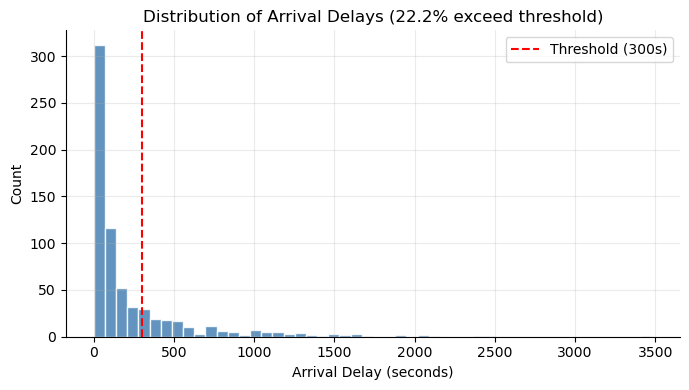

In [6]:
from marta_gnn.visualization.plots import plot_delay_distribution

delays = mock["realtime"]["arrival_delay"].values.astype(float)
fig = plot_delay_distribution(delays, threshold=300)
plt.show()

### Stop Map (ground truth labels)

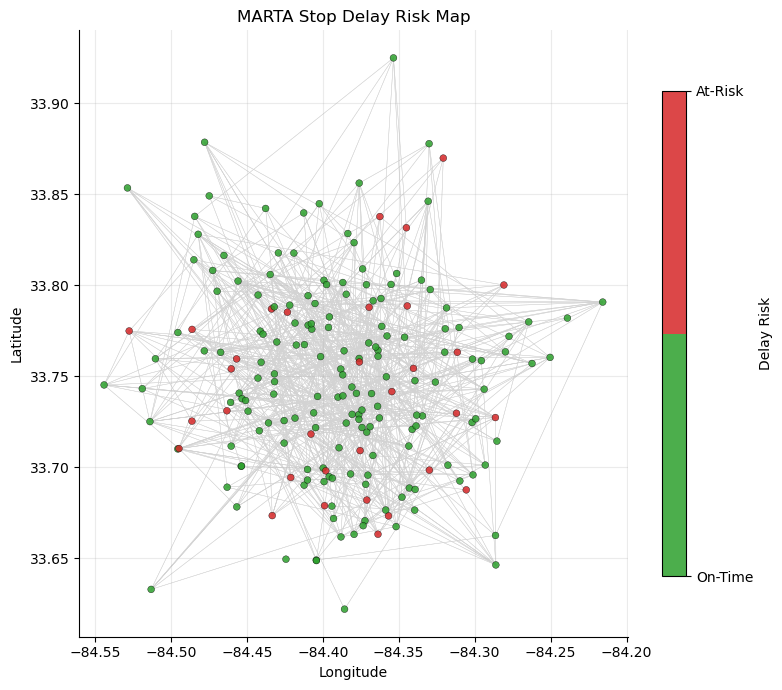

In [7]:
from marta_gnn.visualization.plots import plot_graph_layout

fig = plot_graph_layout(data)
plt.show()

## 4. Train GCN

In [9]:
gcn_model, gcn_history, gcn_results = train_and_evaluate("gcn", data)
print(gcn_model)

Epoch   1 | loss=1.2025 val_loss=7.3181 | acc=0.160 val_acc=0.154 | MAE=0.8093 MSE=0.7874 RMSE=0.8873
Epoch   2 | loss=1.0882 val_loss=4.7368 | acc=0.160 val_acc=0.154 | MAE=0.8019 MSE=0.7761 RMSE=0.8810
Epoch   3 | loss=1.1103 val_loss=3.5520 | acc=0.160 val_acc=0.179 | MAE=0.7943 MSE=0.7624 RMSE=0.8732
Epoch   4 | loss=1.0306 val_loss=2.8337 | acc=0.210 val_acc=0.231 | MAE=0.7879 MSE=0.7478 RMSE=0.8648
Epoch   5 | loss=1.1068 val_loss=2.3556 | acc=0.218 val_acc=0.231 | MAE=0.7805 MSE=0.7298 RMSE=0.8543
Epoch   6 | loss=0.9617 val_loss=2.0043 | acc=0.218 val_acc=0.231 | MAE=0.7706 MSE=0.7069 RMSE=0.8408
Epoch   7 | loss=1.0596 val_loss=1.7340 | acc=0.218 val_acc=0.231 | MAE=0.7583 MSE=0.6798 RMSE=0.8245
Epoch   8 | loss=0.9955 val_loss=1.5230 | acc=0.210 val_acc=0.231 | MAE=0.7442 MSE=0.6497 RMSE=0.8061
Epoch   9 | loss=1.1089 val_loss=1.3604 | acc=0.218 val_acc=0.256 | MAE=0.7283 MSE=0.6181 RMSE=0.7862
Epoch  10 | loss=0.9639 val_loss=1.2330 | acc=0.227 val_acc=0.282 | MAE=0.7110 MSE

GCNModel(
  (convs): ModuleList(
    (0): GCNConv(12, 64)
    (1): GCNConv(64, 2)
  )
  (bns): ModuleList(
    (0): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)


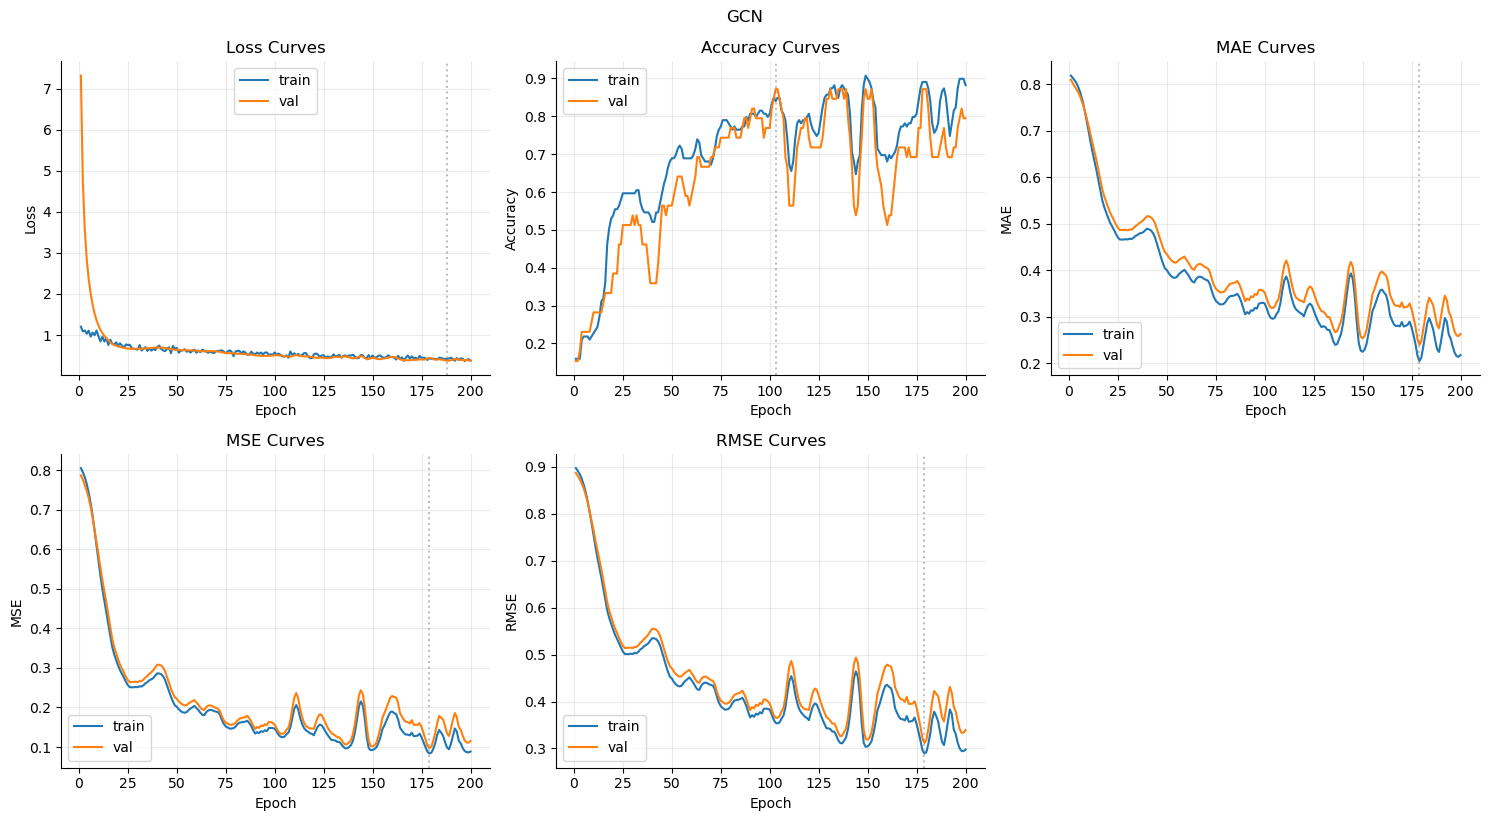

In [10]:
fig = plot_training_curves(gcn_history)
plt.suptitle("GCN", y=1.02); plt.show()

## 5. Train MLP Baseline

In [11]:
mlp_model, mlp_history, mlp_results = train_and_evaluate("mlp", data)

Epoch   1 | loss=0.6694 val_loss=0.6744 | acc=0.294 val_acc=0.333 | MAE=0.5496 MSE=0.3161 RMSE=0.5622
Epoch   2 | loss=0.7244 val_loss=0.6531 | acc=0.319 val_acc=0.462 | MAE=0.5128 MSE=0.2680 RMSE=0.5177
Epoch   3 | loss=0.7188 val_loss=0.6424 | acc=0.403 val_acc=0.538 | MAE=0.4974 MSE=0.2507 RMSE=0.5007
Epoch   4 | loss=0.6219 val_loss=0.6333 | acc=0.504 val_acc=0.615 | MAE=0.4884 MSE=0.2415 RMSE=0.4914
Epoch   5 | loss=0.6560 val_loss=0.6309 | acc=0.521 val_acc=0.615 | MAE=0.4868 MSE=0.2403 RMSE=0.4902
Epoch   6 | loss=0.6440 val_loss=0.6293 | acc=0.496 val_acc=0.641 | MAE=0.4845 MSE=0.2384 RMSE=0.4882
Epoch   7 | loss=0.6807 val_loss=0.6268 | acc=0.555 val_acc=0.641 | MAE=0.4780 MSE=0.2319 RMSE=0.4816
Epoch   8 | loss=0.6077 val_loss=0.6237 | acc=0.664 val_acc=0.692 | MAE=0.4685 MSE=0.2224 RMSE=0.4716
Epoch   9 | loss=0.6364 val_loss=0.6206 | acc=0.773 val_acc=0.846 | MAE=0.4593 MSE=0.2135 RMSE=0.4621
Epoch  10 | loss=0.6040 val_loss=0.6228 | acc=0.849 val_acc=0.821 | MAE=0.4540 MSE

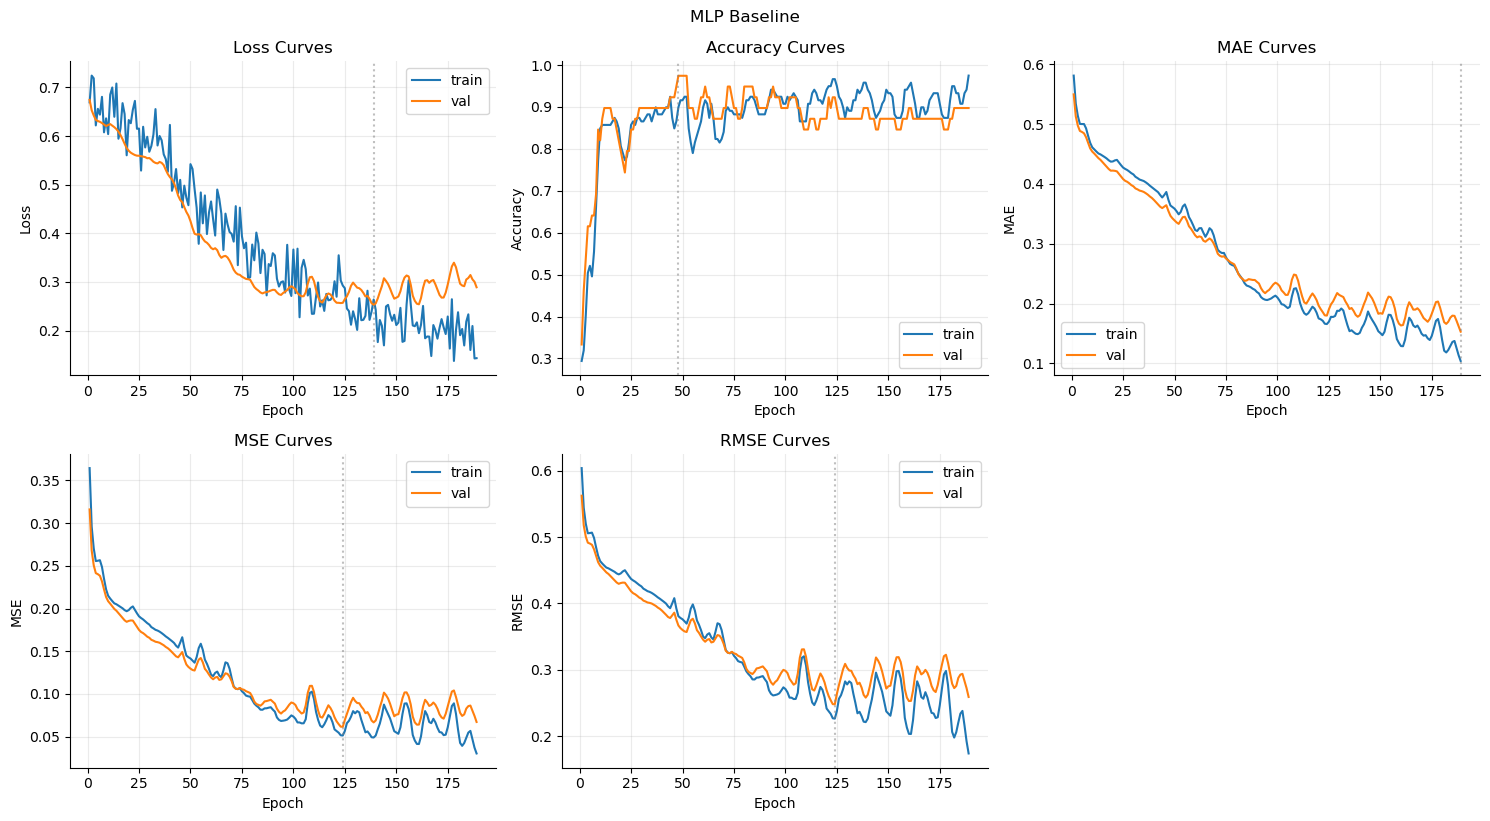

In [12]:
fig = plot_training_curves(mlp_history)
plt.suptitle("MLP Baseline", y=1.02); plt.show()

## 6. Evaluate & Compare

In [13]:
gcn_results = evaluate(gcn_model, data)
mlp_results = evaluate(mlp_model, data)

for name, res in [("GCN", gcn_results), ("MLP", mlp_results)]:
    print(f"{'='*40}\n{name}\n{'='*40}")
    print(res["classification_report"])
    print(f"  MAE:  {res['mae']:.4f}")
    print(f"  MSE:  {res['mse']:.4f}")
    print(f"  RMSE: {res['rmse']:.4f}\n")

Test metrics — acc=0.762  prec=0.400  rec=0.857  f1=0.545  auc=0.824  MAE=0.3180  MSE=0.1516  RMSE=0.3893
Test metrics — acc=0.976  prec=0.875  rec=1.000  f1=0.933  auc=0.992  MAE=0.1487  MSE=0.0464  RMSE=0.2155


GCN
              precision    recall  f1-score   support

     on-time       0.96      0.74      0.84        35
     at-risk       0.40      0.86      0.55         7

    accuracy                           0.76        42
   macro avg       0.68      0.80      0.69        42
weighted avg       0.87      0.76      0.79        42

  MAE:  0.3180
  MSE:  0.1516
  RMSE: 0.3893

MLP
              precision    recall  f1-score   support

     on-time       1.00      0.97      0.99        35
     at-risk       0.88      1.00      0.93         7

    accuracy                           0.98        42
   macro avg       0.94      0.99      0.96        42
weighted avg       0.98      0.98      0.98        42

  MAE:  0.1487
  MSE:  0.0464
  RMSE: 0.2155



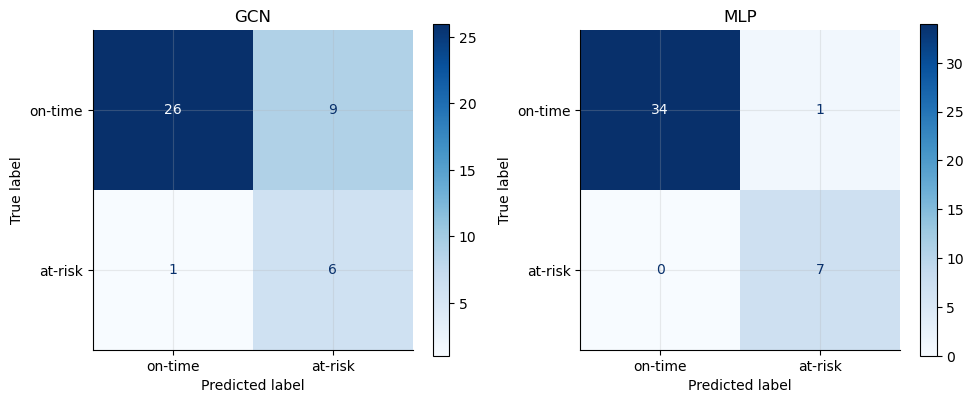

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion_matrix(gcn_results["y_true"], gcn_results["y_pred"], ax=axes[0]); axes[0].set_title("GCN")
plot_confusion_matrix(mlp_results["y_true"], mlp_results["y_pred"], ax=axes[1]); axes[1].set_title("MLP")
plt.tight_layout(); plt.show()

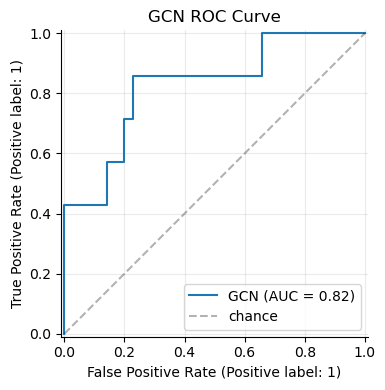

In [15]:
fig = plot_roc_curve(gcn_results["y_true"], gcn_results["y_prob"])
plt.title("GCN ROC Curve")
plt.show()

### Model Comparison Bar Chart

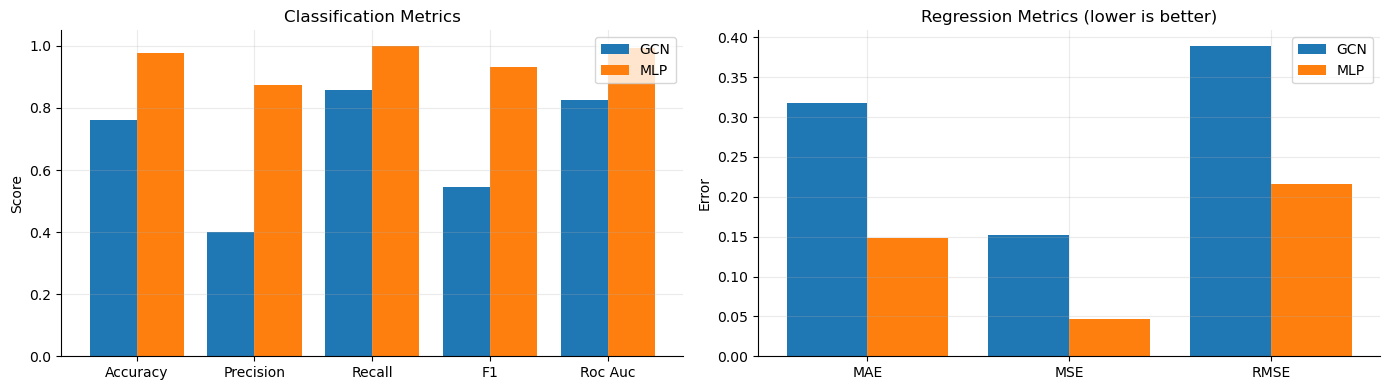

In [16]:
fig = plot_model_comparison({"GCN": gcn_results, "MLP": mlp_results})
plt.show()

### Predicted Stop Map

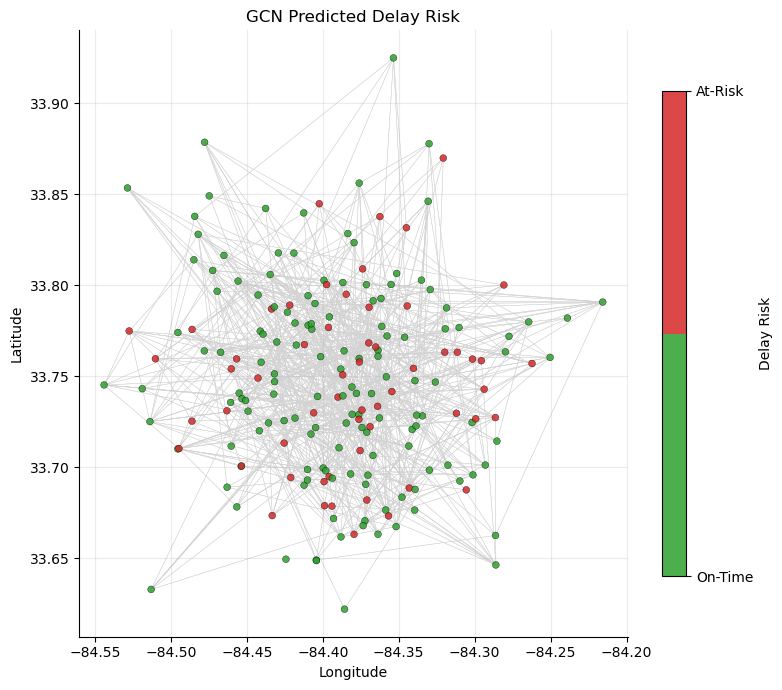

In [17]:
gcn_model.eval()
with torch.no_grad():
    all_preds = model_forward(gcn_model, data).argmax(dim=1).cpu().numpy()

fig = plot_graph_layout(data, predictions=all_preds)
plt.title("GCN Predicted Delay Risk")
plt.show()

## 8. Optuna Hyperparameter Search

Automatically tune GCN hyperparameters by optimising **validation F1**.
Adjust `N_TRIALS` to control how long the search runs.

In [18]:
import optuna
N_TRIALS = 30  # increase for a more thorough search

def objective(trial):
    trial_cfg = {
        "data":     dict(cfg["data"]),
        "features": dict(cfg["features"]),
        "training": dict(cfg["training"]),
        "logging":  dict(cfg["logging"]),
        "model": {
            "type":          "gcn",
            "hidden_dim":    trial.suggest_categorical("hidden_dim", [16, 32, 64, 128]),
            "num_layers":    trial.suggest_int("num_layers", 1, 4),
            "dropout":       trial.suggest_float("dropout", 0.1, 0.6, step=0.05),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
            "weight_decay":  trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True),
            "epochs":        200,
            "patience":      20,
            "batch_size":    32,
        },
    }

    model = build_model(trial_cfg, in_dim=data.x.shape[1])
    Trainer(trial_cfg).train(model, data)
    # Evaluate on VALIDATION set—never peek at test during search
    val_results = evaluate(model, data, mask=data.val_mask)
    # Use macro F1: robust even with few minority-class samples
    return val_results["f1_macro"]

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest Val Macro-F1: {study.best_value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-04-15 07:49:32,240] A new study created in memory with name: no-name-c62dd12a-3a80-4ece-8101-2ff756ff8575


  0%|          | 0/30 [00:00<?, ?it/s]

Epoch   1 | loss=0.7613 val_loss=4.5037 | acc=0.202 val_acc=0.205 | MAE=0.7917 MSE=0.7697 RMSE=0.8773
Epoch   2 | loss=0.7953 val_loss=2.9876 | acc=0.202 val_acc=0.205 | MAE=0.7785 MSE=0.7501 RMSE=0.8661
Epoch   3 | loss=0.7798 val_loss=2.2999 | acc=0.210 val_acc=0.231 | MAE=0.7654 MSE=0.7272 RMSE=0.8527
Epoch   4 | loss=0.7968 val_loss=1.8914 | acc=0.210 val_acc=0.231 | MAE=0.7519 MSE=0.7009 RMSE=0.8372
Epoch   5 | loss=0.8065 val_loss=1.6205 | acc=0.210 val_acc=0.256 | MAE=0.7383 MSE=0.6725 RMSE=0.8201
Epoch   6 | loss=0.8008 val_loss=1.4314 | acc=0.218 val_acc=0.256 | MAE=0.7252 MSE=0.6436 RMSE=0.8022
Epoch   7 | loss=0.8247 val_loss=1.2946 | acc=0.218 val_acc=0.256 | MAE=0.7119 MSE=0.6146 RMSE=0.7840
Epoch   8 | loss=0.7982 val_loss=1.1945 | acc=0.235 val_acc=0.256 | MAE=0.6988 MSE=0.5870 RMSE=0.7662
Epoch   9 | loss=0.7996 val_loss=1.1181 | acc=0.235 val_acc=0.256 | MAE=0.6857 MSE=0.5604 RMSE=0.7486
Epoch  10 | loss=0.7928 val_loss=1.0604 | acc=0.252 val_acc=0.231 | MAE=0.6729 MSE

[I 2026-04-15 07:49:34,551] Trial 0 finished with value: 0.40522875816993464 and parameters: {'hidden_dim': 32, 'num_layers': 1, 'dropout': 0.15000000000000002, 'learning_rate': 0.00013066739238053285, 'weight_decay': 0.003967605077052989}. Best is trial 0 with value: 0.40522875816993464.


Epoch  10 | loss=0.8942 val_loss=0.9462 | acc=0.311 val_acc=0.308 | MAE=0.6424 MSE=0.4790 RMSE=0.6921
Epoch  11 | loss=0.9339 val_loss=0.8892 | acc=0.353 val_acc=0.282 | MAE=0.6179 MSE=0.4422 RMSE=0.6650
Epoch  12 | loss=0.9260 val_loss=0.8503 | acc=0.378 val_acc=0.282 | MAE=0.5981 MSE=0.4131 RMSE=0.6427
Epoch  13 | loss=0.8518 val_loss=0.8188 | acc=0.387 val_acc=0.231 | MAE=0.5790 MSE=0.3857 RMSE=0.6211
Epoch  14 | loss=0.9639 val_loss=0.7952 | acc=0.403 val_acc=0.256 | MAE=0.5633 MSE=0.3636 RMSE=0.6030
Epoch  15 | loss=0.8337 val_loss=0.7747 | acc=0.445 val_acc=0.282 | MAE=0.5473 MSE=0.3423 RMSE=0.5851
Epoch  16 | loss=0.8481 val_loss=0.7621 | acc=0.471 val_acc=0.282 | MAE=0.5328 MSE=0.3231 RMSE=0.5684
Epoch  17 | loss=0.8163 val_loss=0.7462 | acc=0.496 val_acc=0.308 | MAE=0.5243 MSE=0.3120 RMSE=0.5586
Epoch  18 | loss=0.8108 val_loss=0.7330 | acc=0.521 val_acc=0.308 | MAE=0.5105 MSE=0.2948 RMSE=0.5429
Epoch  19 | loss=0.8069 val_loss=0.7217 | acc=0.546 val_acc=0.308 | MAE=0.5014 MSE

...

[I 2026-04-15 07:50:07,767] Trial 27 finished with value: 0.5751633986928104 and parameters: {'hidden_dim': 16, 'num_layers': 3, 'dropout': 0.25, 'learning_rate': 0.009940066161075902, 'weight_decay': 0.00013224906386705542}. Best is trial 4 with value: 0.7367405978784957.


Epoch   6 | loss=0.8345 val_loss=0.7365 | acc=0.269 val_acc=0.308 | MAE=0.5637 MSE=0.3522 RMSE=0.5935
Epoch   7 | loss=1.0657 val_loss=0.8430 | acc=0.218 val_acc=0.231 | MAE=0.6303 MSE=0.4628 RMSE=0.6803
Epoch   8 | loss=0.7638 val_loss=0.9663 | acc=0.218 val_acc=0.231 | MAE=0.6637 MSE=0.5288 RMSE=0.7272
Epoch   9 | loss=0.7754 val_loss=1.0346 | acc=0.218 val_acc=0.231 | MAE=0.6742 MSE=0.5531 RMSE=0.7437
Epoch  10 | loss=0.7874 val_loss=1.0356 | acc=0.218 val_acc=0.231 | MAE=0.6711 MSE=0.5497 RMSE=0.7415
Epoch  11 | loss=0.8821 val_loss=1.0194 | acc=0.235 val_acc=0.256 | MAE=0.6647 MSE=0.5399 RMSE=0.7348
Epoch  12 | loss=0.8092 val_loss=0.9421 | acc=0.252 val_acc=0.256 | MAE=0.6447 MSE=0.5045 RMSE=0.7103
Epoch  13 | loss=0.7935 val_loss=0.8455 | acc=0.269 val_acc=0.256 | MAE=0.6136 MSE=0.4508 RMSE=0.6714
Epoch  14 | loss=0.8094 val_loss=0.7575 | acc=0.311 val_acc=0.308 | MAE=0.5733 MSE=0.3851 RMSE=0.6205
Epoch  15 | loss=0.8299 val_loss=0.7037 | acc=0.361 val_acc=0.333 | MAE=0.5285 MSE

[I 2026-04-15 07:50:11,423] Trial 28 finished with value: 0.7564674397859055 and parameters: {'hidden_dim': 128, 'num_layers': 4, 'dropout': 0.4, 'learning_rate': 0.0014475914053567241, 'weight_decay': 0.0005234229966203272}. Best is trial 28 with value: 0.7564674397859055.


Epoch  11 | loss=0.8997 val_loss=0.8892 | acc=0.218 val_acc=0.282 | MAE=0.6459 MSE=0.4839 RMSE=0.6956
Epoch  12 | loss=1.1247 val_loss=0.8288 | acc=0.252 val_acc=0.282 | MAE=0.6232 MSE=0.4491 RMSE=0.6702
Epoch  13 | loss=0.9963 val_loss=0.7793 | acc=0.261 val_acc=0.308 | MAE=0.6023 MSE=0.4173 RMSE=0.6460
Epoch  14 | loss=0.7749 val_loss=0.7411 | acc=0.294 val_acc=0.308 | MAE=0.5837 MSE=0.3891 RMSE=0.6238
Epoch  15 | loss=0.8156 val_loss=0.7215 | acc=0.328 val_acc=0.359 | MAE=0.5725 MSE=0.3726 RMSE=0.6104
Epoch  16 | loss=0.8265 val_loss=0.6978 | acc=0.353 val_acc=0.385 | MAE=0.5566 MSE=0.3496 RMSE=0.5913
Epoch  17 | loss=0.8273 val_loss=0.6820 | acc=0.403 val_acc=0.385 | MAE=0.5428 MSE=0.3304 RMSE=0.5748
Epoch  18 | loss=0.7718 val_loss=0.6705 | acc=0.445 val_acc=0.385 | MAE=0.5314 MSE=0.3154 RMSE=0.5616
Epoch  19 | loss=0.9380 val_loss=0.6637 | acc=0.487 val_acc=0.385 | MAE=0.5209 MSE=0.3027 RMSE=0.5502
Epoch  20 | loss=0.8537 val_loss=0.6566 | acc=0.563 val_acc=0.385 | MAE=0.5077 MSE

[I 2026-04-15 07:50:12,483] Trial 29 finished with value: 0.44285714285714284 and parameters: {'hidden_dim': 32, 'num_layers': 4, 'dropout': 0.4, 'learning_rate': 0.0013651020068674634, 'weight_decay': 0.004046300871922785}. Best is trial 28 with value: 0.7564674397859055.

Best Val Macro-F1: 0.7565
Best hyperparameters:
  hidden_dim: 128
  num_layers: 4
  dropout: 0.4
  learning_rate: 0.0014475914053567241
  weight_decay: 0.0005234229966203272


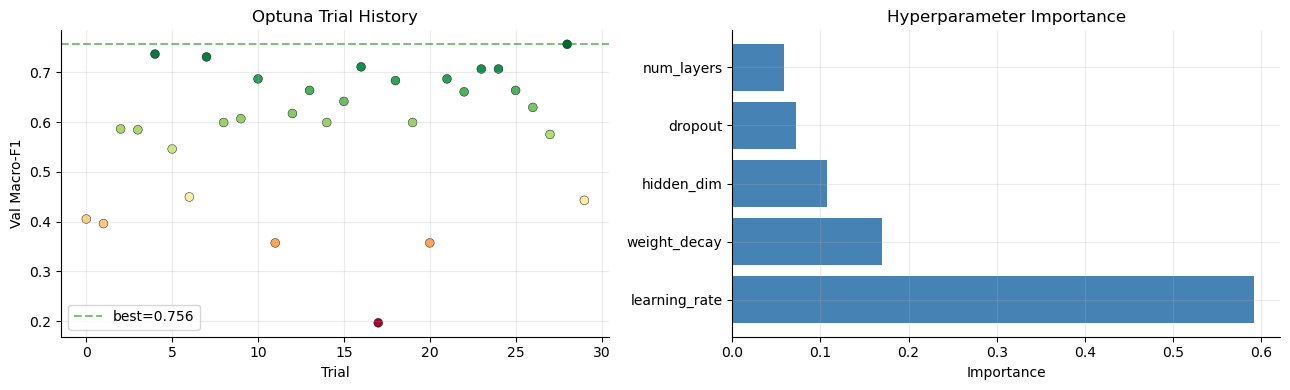

In [19]:
# Visualise search results
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Trial history
trials_df = study.trials_dataframe()
axes[0].scatter(trials_df["number"], trials_df["value"], c=trials_df["value"],
                cmap="RdYlGn", edgecolors="k", linewidths=0.3, s=40)
axes[0].axhline(study.best_value, color="green", linestyle="--", alpha=0.5, label=f"best={study.best_value:.3f}")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("Val Macro-F1"); axes[0].set_title("Optuna Trial History")
axes[0].legend()

# Parameter importances (fANOVA needs variance across trials)
try:
    importances = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importances.keys()), list(importances.values()), color="steelblue")
    axes[1].set_xlabel("Importance"); axes[1].set_title("Hyperparameter Importance")
except RuntimeError:
    axes[1].text(0.5, 0.5, "Importance unavailable\n(too little variance across trials)",
                 ha="center", va="center", transform=axes[1].transAxes, fontsize=11)
    axes[1].set_title("Hyperparameter Importance")

plt.tight_layout(); plt.show()

In [20]:
# Retrain with the best hyperparameters
best = study.best_params
best_cfg = {
    "data":     dict(cfg["data"]),
    "features": dict(cfg["features"]),
    "training": dict(cfg["training"]),
    "logging":  dict(cfg["logging"]),
    "model": {
        "type": "gcn",
        "hidden_dim":    best["hidden_dim"],
        "num_layers":    best["num_layers"],
        "dropout":       best["dropout"],
        "learning_rate": best["learning_rate"],
        "weight_decay":  best["weight_decay"],
        "epochs": 200,
        "patience": 20,
        "batch_size": 32,
    },
}

best_model = build_model(best_cfg, in_dim=data.x.shape[1])
best_history = Trainer(best_cfg).train(best_model, data)
best_results = evaluate(best_model, data)

print("Optimised GCN:")
print(best_results["classification_report"])
print(f"  MAE:  {best_results['mae']:.4f}")
print(f"  MSE:  {best_results['mse']:.4f}")
print(f"  RMSE: {best_results['rmse']:.4f}")
print(f"\nF1: {best_results['f1']:.4f}  |  ROC-AUC: {best_results['roc_auc']:.4f}")

Epoch   1 | loss=1.4219 val_loss=1.4874 | acc=0.168 val_acc=0.179 | MAE=0.7664 MSE=0.6841 RMSE=0.8271
Epoch   2 | loss=1.3452 val_loss=1.0181 | acc=0.731 val_acc=0.769 | MAE=0.4118 MSE=0.2083 RMSE=0.4564
Epoch   3 | loss=1.2155 val_loss=1.5134 | acc=0.840 val_acc=0.846 | MAE=0.2577 MSE=0.1541 RMSE=0.3925
Epoch   4 | loss=0.9605 val_loss=1.5469 | acc=0.840 val_acc=0.846 | MAE=0.2318 MSE=0.1465 RMSE=0.3828
Epoch   5 | loss=1.0969 val_loss=1.3117 | acc=0.840 val_acc=0.846 | MAE=0.2407 MSE=0.1412 RMSE=0.3758
Epoch   6 | loss=0.8513 val_loss=1.3097 | acc=0.840 val_acc=0.846 | MAE=0.2327 MSE=0.1395 RMSE=0.3735
Epoch   7 | loss=0.8363 val_loss=1.0947 | acc=0.840 val_acc=0.846 | MAE=0.2615 MSE=0.1395 RMSE=0.3734
Epoch   8 | loss=1.0852 val_loss=0.7982 | acc=0.840 val_acc=0.795 | MAE=0.3387 MSE=0.1554 RMSE=0.3942
Epoch   9 | loss=0.9693 val_loss=0.6648 | acc=0.714 val_acc=0.615 | MAE=0.4330 MSE=0.2124 RMSE=0.4609
Epoch  10 | loss=0.7817 val_loss=0.6531 | acc=0.445 val_acc=0.436 | MAE=0.4859 MSE

Optimised GCN:
              precision    recall  f1-score   support

     on-time       0.73      0.23      0.35        35
     at-risk       0.13      0.57      0.21         7

    accuracy                           0.29        42
   macro avg       0.43      0.40      0.28        42
weighted avg       0.63      0.29      0.32        42

  MAE:  0.5401
  MSE:  0.3021
  RMSE: 0.5496

F1: 0.2105  |  ROC-AUC: 0.4653


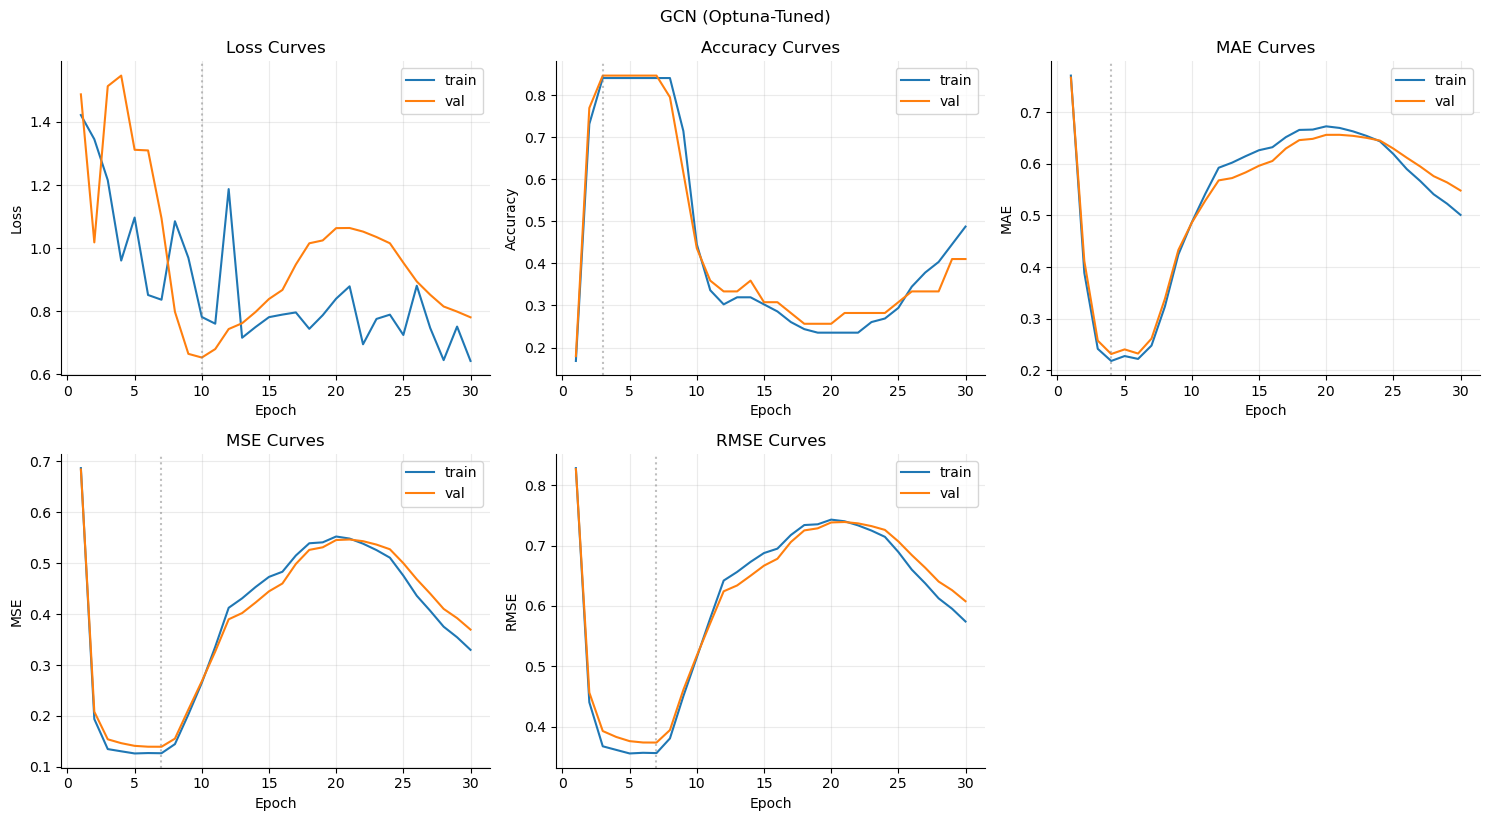

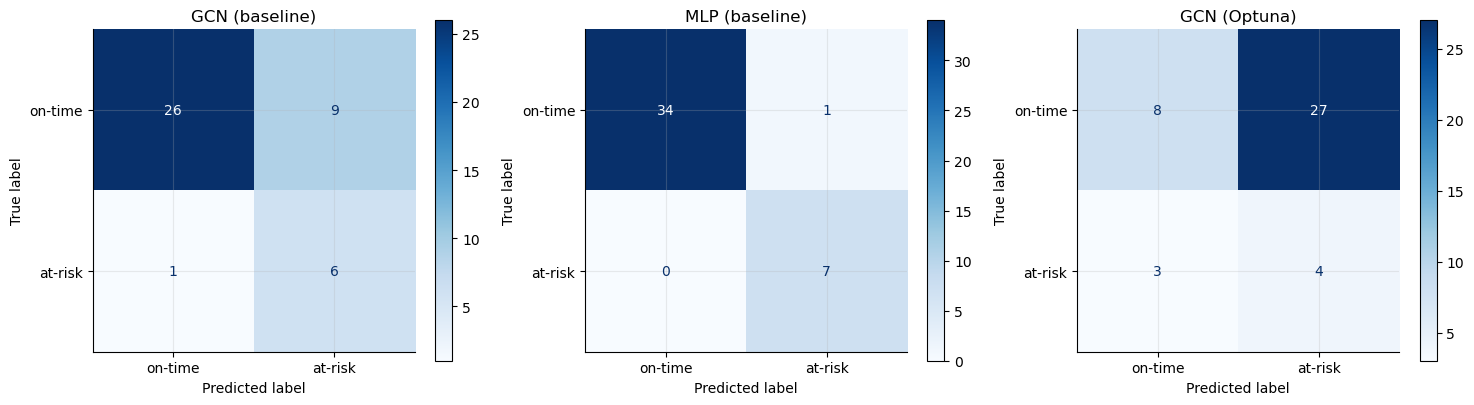

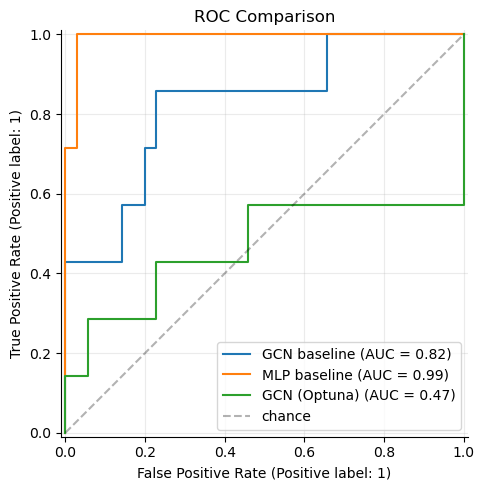

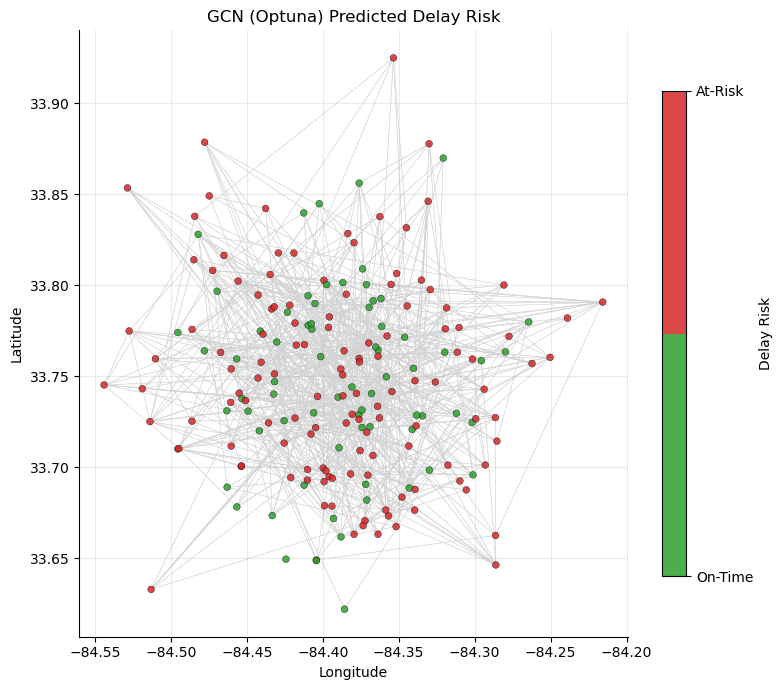

In [21]:
# ── Optuna model: training curves ──
fig = plot_training_curves(best_history)
plt.suptitle("GCN (Optuna-Tuned)", y=1.02)
plt.show()

# ── Side-by-side confusion matrices: all three models ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_confusion_matrix(gcn_results["y_true"], gcn_results["y_pred"], ax=axes[0]); axes[0].set_title("GCN (baseline)")
plot_confusion_matrix(mlp_results["y_true"], mlp_results["y_pred"], ax=axes[1]); axes[1].set_title("MLP (baseline)")
plot_confusion_matrix(best_results["y_true"], best_results["y_pred"], ax=axes[2]); axes[2].set_title("GCN (Optuna)")
plt.tight_layout(); plt.show()

# ── ROC curves overlay ──
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(gcn_results["y_true"], gcn_results["y_prob"], ax=ax, name="GCN baseline")
RocCurveDisplay.from_predictions(mlp_results["y_true"], mlp_results["y_prob"], ax=ax, name="MLP baseline")
RocCurveDisplay.from_predictions(best_results["y_true"], best_results["y_prob"], ax=ax, name="GCN (Optuna)")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="chance")
ax.set_title("ROC Comparison"); ax.legend()
plt.tight_layout(); plt.show()

# ── Predicted stop map with Optuna model ──
best_model.eval()
with torch.no_grad():
    optuna_preds = model_forward(best_model, data).argmax(dim=1).cpu().numpy()
fig = plot_graph_layout(data, predictions=optuna_preds)
plt.title("GCN (Optuna) Predicted Delay Risk")
plt.show()

In [22]:
models = ["GCN", "MLP", "GCN (Optuna)"]
results_list = [gcn_results, mlp_results, best_results]

summary = pd.DataFrame({
    "Model":      models,
    "Accuracy":   [r["accuracy"]  for r in results_list],
    "Precision":  [r["precision"] for r in results_list],
    "Recall":     [r["recall"]    for r in results_list],
    "F1":         [r["f1"]        for r in results_list],
    "F1-Macro":   [r["f1_macro"]  for r in results_list],
    "ROC-AUC":    [r["roc_auc"]   for r in results_list],
    "MAE":        [r["mae"]       for r in results_list],
    "MSE":        [r["mse"]       for r in results_list],
    "RMSE":       [r["rmse"]      for r in results_list],
}).round(4)

higher_better = ["Accuracy", "Precision", "Recall", "F1", "F1-Macro", "ROC-AUC"]
lower_better  = ["MAE", "MSE", "RMSE"]

(summary.style
    .highlight_max(subset=higher_better, color="black")
    .highlight_min(subset=lower_better, color="black")
)

,Model,Accuracy,Precision,Recall,F1,F1-Macro,ROC-AUC,MAE,MSE,RMSE
0,GCN,0.761900,0.400000,0.857100,0.545500,0.692100,0.824500,0.318000,0.151600,0.389300
1,MLP,0.976200,0.875000,1.000000,0.933300,0.959400,0.991800,0.148700,0.046400,0.215500
2,GCN (Optuna),0.285700,0.129000,0.571400,0.210500,0.279200,0.465300,0.540100,0.302100,0.549600


For real data: `python -m marta_gnn.main --live`